dict_keys(['Iter', 'L', 'LE', 'LF', 'LOBS0', 'ESS0', 'OBS_REW_0_0', 'OBS_UNREW_0_0', 'OBS_0_0', 'Time'])
(1318, 10)


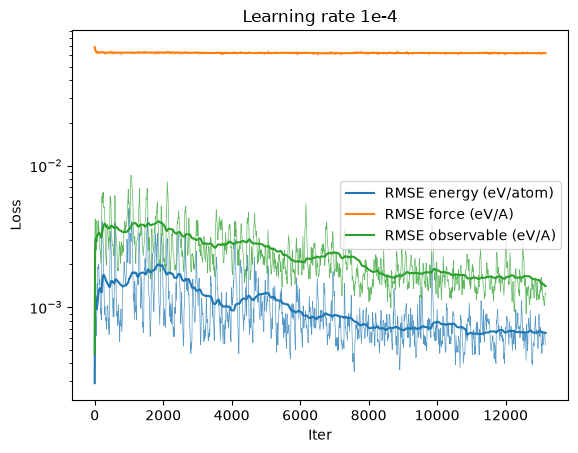

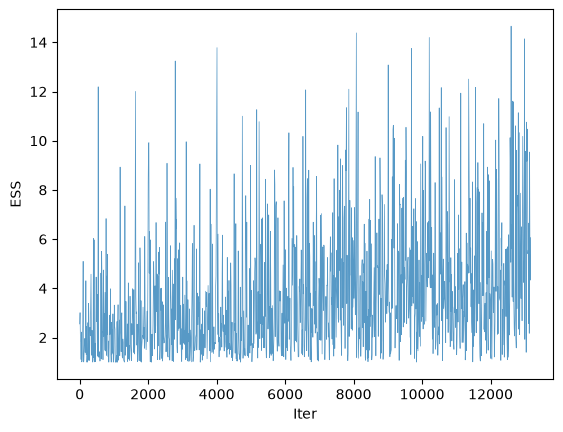

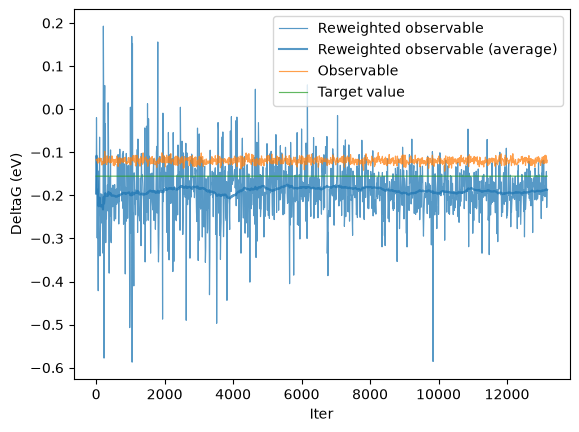

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def parse_line(line):
    tokens = line.split() #line.split()  Split the line into tokens
    data = {}
    i = 0
    while i < len(tokens):
        key = tokens[i]
        value = tokens[i + 1]

        # Remove trailing 's' from Time
        if value.endswith('s'):
            value = value[:-1]

        # Try to convert to int or float
        try:
            if '.' in value:
                value = float(value)
            else:
                value = int(value)
        except ValueError:
            pass

        data[key] = value
        i += 2 #esto es porque cada par de tokens es un key y un value, entonces se incrementa en 2 para pasar al siguiente par

    return data

results = []
with open("./log.txt") as f:
    for line in f:
        if line.startswith("Iter"):
            results.append(parse_line(line)) #la salida es una lista de diccionarios, donde cada diccionario contiene los datos de una línea del log

keys = results[0].keys()
array = np.array([[row[k] for k in keys] for row in results])

print(keys)
print(array.shape)

def running_avg(x, w):
    cumsum = np.cumsum(np.insert(x, 0, 0)) #introduce un 0 al principio de la suma acumulativa para facilitar el cálculo del promedio
    out = np.empty_like(x, dtype=float)
    for i in range(len(x)):
        start = max(0, i - w + 1)
        count = i - start + 1
        out[i] = (cumsum[i+1] - cumsum[start]) / count
    return out

Nignore=0
everyN=1
window = 100

colors = ['C0', 'C1', 'C2']
x = array[Nignore::everyN, 0]
y1 = array[Nignore::everyN, 2]
y2 = array[Nignore::everyN, 3]
y3 = array[Nignore::everyN,4]
ess= array[Nignore::everyN,5]
obs_rew= array[Nignore::everyN,6]
obs_unrew= array[Nignore::everyN,7]
target= -15.*0.010364269666250866*np.ones(len(x))

y1_avg = running_avg(y1, window)
y2_avg = running_avg(y2, window)
y3_avg = running_avg(y3, window)
rew_avg = running_avg(obs_rew, window)

plt.figure()
plt.plot(x, y1,color=colors[0],alpha=0.75, linewidth=0.5)
plt.plot(x, y2,color=colors[1],alpha=0.75, linewidth=0.5)
plt.plot(x, y3,color=colors[2],alpha=0.75, linewidth=0.5)
plt.plot(x, y1_avg, label="RMSE energy (eV/atom)",color=colors[0], linewidth=1.5)
plt.plot(x, y2_avg, label="RMSE force (eV/A)",color=colors[1], linewidth=1.5)
plt.plot(x, y3_avg, label="RMSE observable (eV/A)",color=colors[2], linewidth=1.5)
plt.title("Learning rate 1e-4")
plt.xlabel("Iter")
plt.ylabel("Loss")
plt.yscale("log")
plt.legend()
plt.show()



plt.figure()
plt.plot(x,ess,color=colors[0],alpha=0.75, linewidth=0.5)
plt.xlabel("Iter")
plt.ylabel("ESS")
plt.show()

plt.figure()
plt.plot(x, obs_rew ,color=colors[0],label="Reweighted observable",alpha=0.75, linewidth=0.85)
plt.plot(x, rew_avg ,color=colors[0],label="Reweighted observable (average)",alpha=0.75, linewidth=1.5)
plt.plot(x, obs_unrew,color=colors[1],label="Observable",alpha=0.75, linewidth=0.85)
plt.plot(x, target,color=colors[2],label="Target value",alpha=0.75, linewidth=0.85)
plt.xlabel("Iter")
plt.ylabel("DeltaG (eV)")
plt.legend()
plt.show()